# Week 8 Capstone Project: End-to-End Machine Learning Pipeline
## MSDS 680 - Machine Learning

---

**Points:** 150 (1.5x weight)  
**Due:** End of Week 8

---

## Overview

Demonstrate mastery of the entire ML workflow by tackling a real-world prediction problem. Apply techniques from all previous weeks, make domain-appropriate decisions, and communicate results to both technical and non-technical audiences.

## Project Options

Choose ONE:
- **Option A:** Employee Attrition (HR Analytics)
- **Option B:** Customer Churn (Telecom)
- **Option C:** Loan Default (Finance)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, classification_report, roc_curve, auc,
                            roc_auc_score, precision_recall_curve, average_precision_score)
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


---

## Part 1: Problem Definition & Data Understanding (15 points)

### 1.1 Problem Statement (5 points)

**PROBLEM STATEMENT:**

- **Business Problem:** Banks must maintain a balanced loan portfolio by managing profitability and risk. High default rates can negatively impact revenue and financial stability. The objective is to predict potential loan defaults to identify hihgh-risk borrowers so that financial institutions can better manage their credit portfolios. 
This project develops a machine learning classification model to predict loan defaults using the Loan Default dataset (Option C).

- **Stakeholder Needs:** Stakeholder seek tools and insights to manage loan risk: risk managers focus on identifying high- risk borrowers early in the approval process. 
The model must prioritize catching actual defaults over avoiding false alarms, since the cost of an undetected default exceeds the cost of an unnecessary rejection. 

- **Success Criteria:**
  - Identify high risk borrowers accurately 
  - Reduce overall portfolio default rate
  - Provide insights into key risk factors.
  - ROC-AUC ≥ 0.80 on the held-out test set
  - F1-score ≥ 0.75 for the default class
  - Recall for defaults ≥ 0.75 (minimize missed defaults)
  - Model must be explainable via feature importances for regulatory use


### 1.2 Data Exploration (10 points)

In [2]:
# YOUR CODE HERE: Load your chosen dataset
#Importing dataset
df = pd.read_csv("Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
# YOUR CODE HERE: Summary statistics, target distribution, missing values
#Dataset shape and column data types
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nColumn Data Types:")
print(df.dtypes.to_string())

Dataset Shape: 255,347 rows × 18 columns

Column Data Types:
LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64


In [4]:
#Target variable distribution
target_col    = 'Default'
target_counts = df[target_col].value_counts().sort_index()
target_pct    = df[target_col].value_counts(normalize=True).sort_index() * 100

print(f"TARGET VARIABLE ({target_col}) DISTRIBUTION")
print("="*40)
for label in target_counts.index:
    print(f"  Class {label}: {target_counts[label]:,}  ({target_pct[label]:.1f}%)")

if len(target_counts) == 2:
    majority, minority = target_counts.iloc[1], target_counts.iloc[0]
    print(f"  Class Imbalance Ratio: {majority/minority:.1f}:1 (non-default:default)")

TARGET VARIABLE (Default) DISTRIBUTION
  Class 0: 225,694  (88.4%)
  Class 1: 29,653  (11.6%)
  Class Imbalance Ratio: 0.1:1 (non-default:default)


In [5]:
#Missing values analysis
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_info = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("MISSING VALUES BY COLUMN")
print("="*40)
if len(missing_info) > 0:
    print(missing_info.to_string())
    print(f"\nTotal missing cells: {missing.sum():,} of {df.size:,} ({missing.sum()/df.size*100:.2f}%)")
else:
    print("  No missing values found.")

MISSING VALUES BY COLUMN
  No missing values found.


In [6]:
#Numeric summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9
Default,255347.0,0.116128,0.320379,0.0,0.00,0.00,0.00,1.0


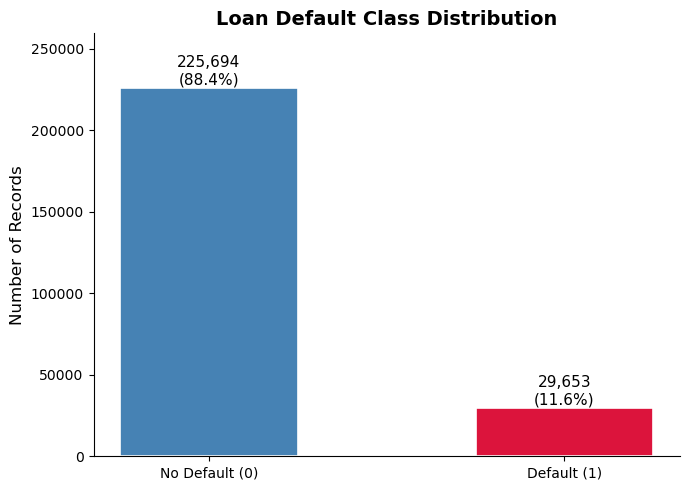

In [7]:
# YOUR CODE HERE: At least 10 meaningful visualizations
#Bar chart: Default class distribution
counts = df['Default'].value_counts().sort_index()
labels = ['No Default (0)', 'Default (1)']
colors = ['steelblue', 'crimson']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.2, width=0.5)

for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 400,
            f'{v:,}\n({v / len(df) * 100:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_title('Loan Default Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Records', fontsize=12)
ax.set_ylim(0, counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

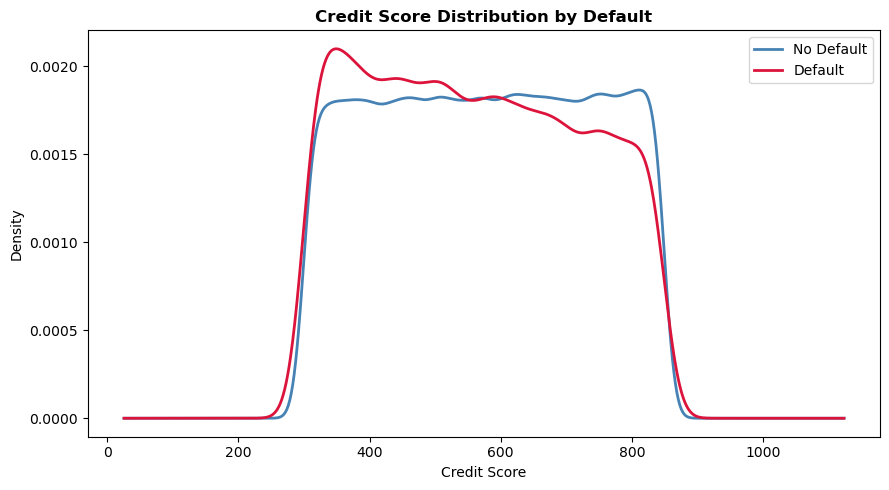

In [8]:
#KDE: Credit Score distribution by Default status
fig, ax = plt.subplots(figsize=(9, 5))

for label, color, lbl in [(0, 'steelblue', 'No Default'), (1, 'crimson', 'Default')]:
    df[df['Default'] == label]['CreditScore'].plot(
        kind='kde', ax=ax, color=color, label=lbl, linewidth=2)

ax.set_title('Credit Score Distribution by Default', fontweight='bold')
ax.set_xlabel('Credit Score')
ax.legend()
plt.tight_layout()
plt.show()


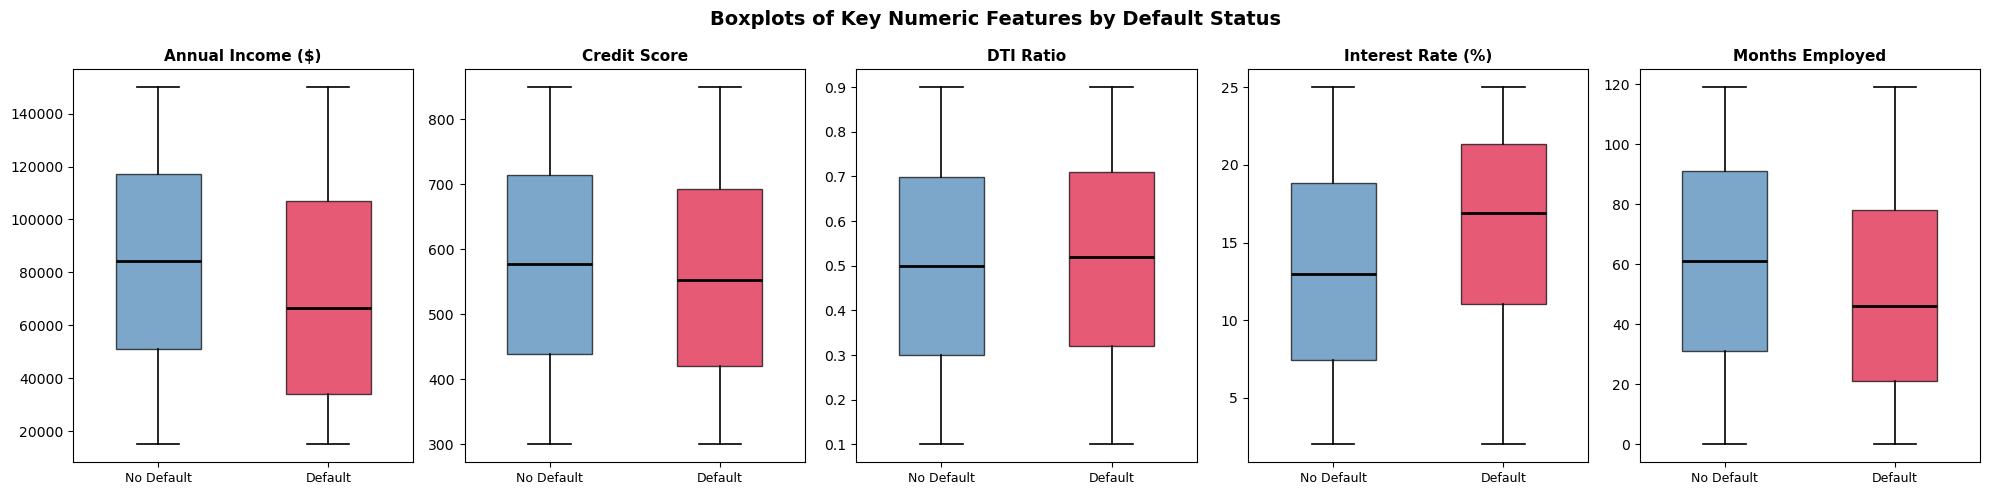

In [9]:
#Boxplots by Default status for 5 key numeric features
features = ['Income', 'CreditScore', 'DTIRatio', 'InterestRate', 'MonthsEmployed']
titles   = ['Annual Income ($)', 'Credit Score', 'DTI Ratio', 'Interest Rate (%)', 'Months Employed']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Boxplots of Key Numeric Features by Default Status', fontsize=14, fontweight='bold')

for ax, feat, title in zip(axes, features, titles):
    data = [df[df['Default'] == 0][feat].values,
            df[df['Default'] == 1][feat].values]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2))
    for patch, color in zip(bp['boxes'], ['steelblue', 'crimson']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['No Default', 'Default'], fontsize=9)

plt.tight_layout()
plt.show()

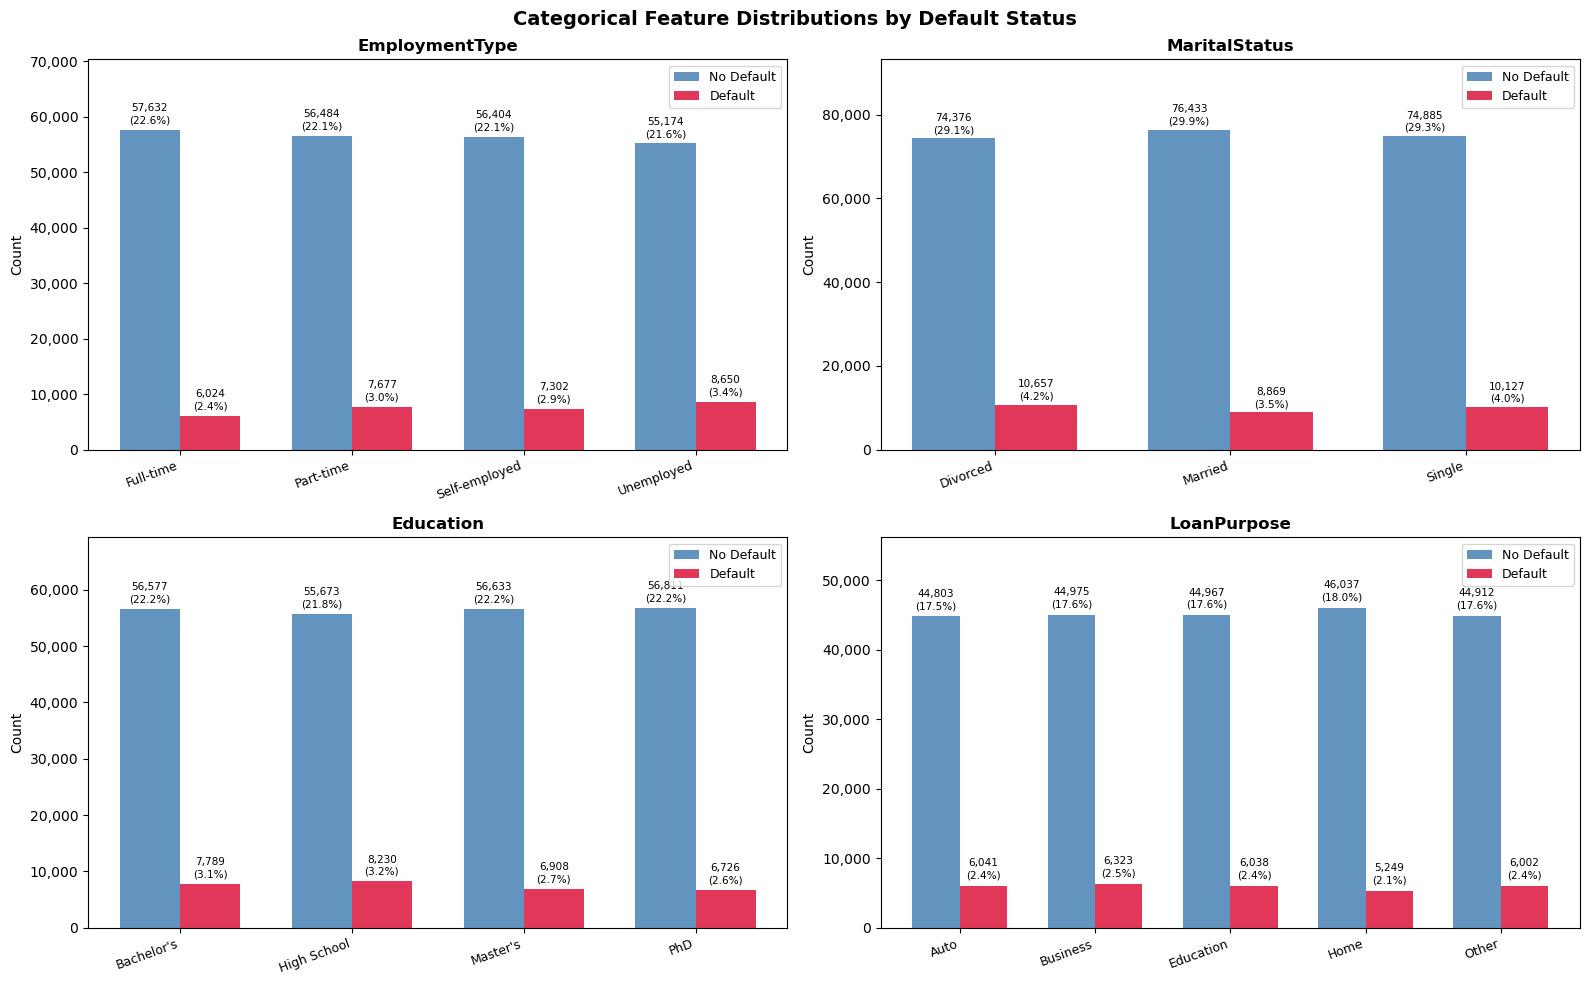

In [10]:
#Grouped bar charts for categorical features with count + percentage labels
cat_features = ['EmploymentType', 'MaritalStatus', 'Education', 'LoanPurpose']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Categorical Feature Distributions by Default Status', fontsize=14, fontweight='bold')

total = len(df)

for ax, feat in zip(axes.flat, cat_features):
    counts = df.groupby([feat, 'Default']).size().unstack(fill_value=0)
    categories = counts.index.tolist()
    x = np.arange(len(categories))
    width = 0.35

    bars0 = ax.bar(x - width/2, counts[0], width, label='No Default', color='steelblue', alpha=0.85)
    bars1 = ax.bar(x + width/2, counts[1], width, label='Default',    color='crimson',   alpha=0.85)

    # Add count + percentage labels above each bar
    for bars in (bars0, bars1):
        for bar in bars:
            v = int(bar.get_height())
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + total * 0.003,
                        f'{v:,}\n({v/total*100:.1f}%)',
                        ha='center', va='bottom', fontsize=7.5, linespacing=1.3)

    ax.set_title(feat, fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.values.max() * 1.22)
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.tight_layout()
plt.show()

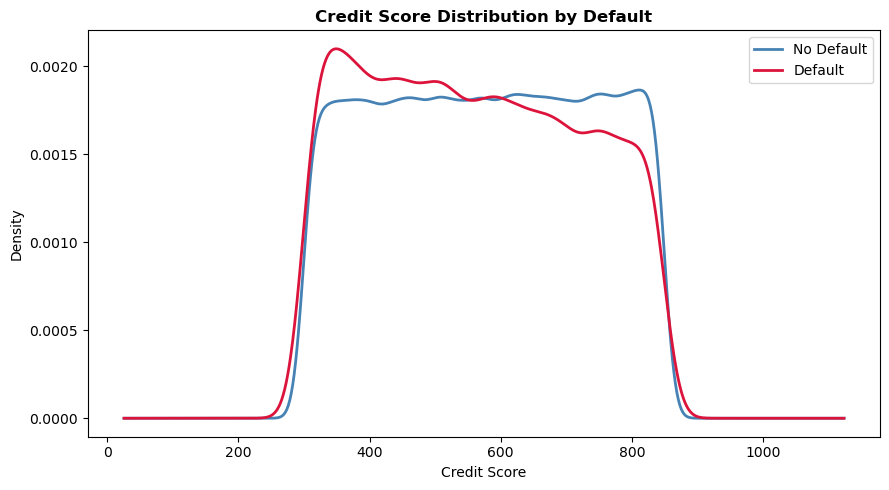

In [11]:
#KDE: Credit Score distribution by Default status
fig, ax = plt.subplots(figsize=(9, 5))

for label, color, lbl in [(0, 'steelblue', 'No Default'), (1, 'crimson', 'Default')]:
    df[df['Default'] == label]['CreditScore'].plot(
        kind='kde', ax=ax, color=color, label=lbl, linewidth=2)

ax.set_title('Credit Score Distribution by Default', fontweight='bold')
ax.set_xlabel('Credit Score')
ax.legend()
plt.tight_layout()
plt.show()

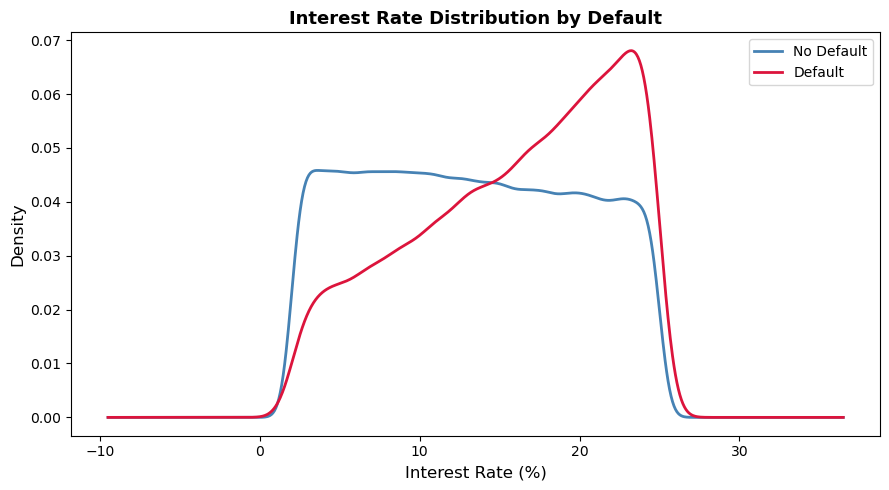

In [12]:
#KDE: Interest Rate distribution by Default status
fig, ax = plt.subplots(figsize=(9, 5))

for label, color, lbl in [(0, 'steelblue', 'No Default'), (1, 'crimson', 'Default')]:
    df[df['Default'] == label]['InterestRate'].plot(
        kind='kde', ax=ax, color=color, label=lbl, linewidth=2)

ax.set_title('Interest Rate Distribution by Default', fontsize=13, fontweight='bold')
ax.set_xlabel('Interest Rate (%)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---

## Part 2: Data Preprocessing & Feature Engineering (20 points)

### 2.1 Data Cleaning (10 points)

In [13]:
# YOUR CODE HERE: Handle missing values, outliers, encode categoricals
# ── Data Cleaning
df_clean = df.copy()

#Drop identifier column (no predictive value)
df_clean.drop('LoanID', axis=1, inplace=True)

#Encode binary Yes/No columns to 0/1
binary_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})
print(f"Binary encoded: {binary_cols}")

#Ordinal-encode Education (ordered hierarchy)
edu_order = {"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3}
df_clean['Education'] = df_clean['Education'].map(edu_order)
print(f"Ordinal encoded: Education → {edu_order}")

#One-hot encode remaining categorical columns
cat_cols = ['EmploymentType', 'MaritalStatus', 'LoanPurpose']
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
print(f"One-hot encoded: {cat_cols}")

Binary encoded: ['HasMortgage', 'HasDependents', 'HasCoSigner']
Ordinal encoded: Education → {'High School': 0, "Bachelor's": 1, "Master's": 2, 'PhD': 3}
One-hot encoded: ['EmploymentType', 'MaritalStatus', 'LoanPurpose']


In [14]:
#Cap outliers using IQR
numeric_to_cap = ['Income', 'LoanAmount', 'MonthsEmployed', 'NumCreditLines', 'InterestRate']
outlier_report = {}
for col in numeric_to_cap:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)
    outlier_report[col] = n_outliers

print(f"\nOutliers capped (IQR ×1.5):")
for col, n in outlier_report.items():
    print(f"  {col:<20}: {n:,} values capped")

print(f"\nCleaned dataset shape : {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")
print(f"\nFinal columns ({df_clean.shape[1]} total):\n  {list(df_clean.columns)}")


Outliers capped (IQR ×1.5):
  Income              : 0 values capped
  LoanAmount          : 0 values capped
  MonthsEmployed      : 0 values capped
  NumCreditLines      : 0 values capped
  InterestRate        : 0 values capped

Cleaned dataset shape : (255347, 23)
Missing values remaining: 0

Final columns (23 total):
  ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'Default', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']


### 2.2 Feature Engineering (10 points)

In [15]:
# YOUR CODE HERE: Create at least 3 new features with justification
#Feature 1: Loan-to-Income Ratio
df_clean['LoanToIncomeRatio'] = df_clean['LoanAmount'] / (df_clean['Income'] + 1)

#Feature 2: Monthly Interest Burden
df_clean['MonthlyInterestBurden'] = (
    df_clean['LoanAmount'] * (df_clean['InterestRate'] / 100)
) / df_clean['LoanTerm']

#Feature 3: Credit-DTI Composite Risk Score
df_clean['CreditDTIRisk'] = df_clean['DTIRatio'] * (1 - df_clean['CreditScore'] / 850)

#Feature 4: Employment Stability (years)
df_clean['YearsEmployed'] = df_clean['MonthsEmployed'] / 12

# Feature 5: Income per Credit Line
df_clean['IncomePerCreditLine'] = df_clean['Income'] / (df_clean['NumCreditLines'] + 1)

#Display summary statistics for new features
df_clean[['LoanToIncomeRatio', 'MonthlyInterestBurden', 'CreditDTIRisk',
          'YearsEmployed', 'IncomePerCreditLine', 'Default']].describe().round(4)

,LoanToIncomeRatio,MonthlyInterestBurden,CreditDTIRisk,YearsEmployed,IncomePerCreditLine,Default
count,255347.0000,255347.0000,255347.0000,255347.0000,255347.0000,255347.0000
mean,2.1774,653.4932,0.1623,4.9618,26458.9178,0.1161
std,2.1783,739.0698,0.1274,2.8869,16251.2146,0.3204
min,0.0337,2.0771,0.0001,0.0000,3000.0000,0.0000
25%,0.8036,174.7411,0.0589,2.5000,13925.1667,0.0000
50%,1.5467,409.8287,0.1297,5.0000,23567.6000,0.0000
75%,2.6717,830.1775,0.2416,7.5000,35009.5833,0.0000
max,16.5314,5180.9697,0.5824,9.9167,74998.5000,1.0000


In [16]:
# YOUR CODE HERE: Train/validation/test split and scaling
#Separate features and target
X = df_clean.drop('Default', axis=1)
y = df_clean['Default']

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")
print(f"Class balance    → 0 (no default): {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)"
      f"  |  1 (default): {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)")

Feature matrix X : (255347, 27)
Target vector  y : (255347,)
Class balance    → 0 (no default): 225,694 (88.4%)  |  1 (default): 29,653 (11.6%)


In [17]:
#Split 1 — 70% train, 30% temp 
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

#Split 2 — split temp 50/50 to 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\nDataset splits (stratified):")
print(f"  Train      : {X_train.shape[0]:>7,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Validation : {X_val.shape[0]:>7,} rows  ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"  Test       : {X_test.shape[0]:>7,} rows  ({X_test.shape[0]/len(X)*100:.0f}%)")


Dataset splits (stratified):
  Train      : 178,742 rows  (70%)
  Validation :  38,302 rows  (15%)
  Test       :  38,303 rows  (15%)


In [18]:
#Fit StandardScaler on training data only toprevents data leakage
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_val_sc    = scaler.transform(X_val)
X_test_sc   = scaler.transform(X_test)

print(f"\nStandardScaler applied — fit on train only, transform on val/test")
print(f"Total features: {X.shape[1]}")
print(f"Feature names : {list(X.columns)}")


StandardScaler applied — fit on train only, transform on val/test
Total features: 27
Feature names : ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 'LoanToIncomeRatio', 'MonthlyInterestBurden', 'CreditDTIRisk', 'YearsEmployed', 'IncomePerCreditLine']


---

## Part 3: Model Development (40 points)

### 3.1 Baseline Model (5 points)

In [19]:
# YOUR CODE HERE: Establish simple baseline
#Baseline Model: Majority-Class Dummy Classifier
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_sc, y_train)
y_dummy_pred = dummy.predict(X_val_sc)
y_dummy_prob = dummy.predict_proba(X_val_sc)[:, 1]

print("BASELINE: Majority-Class Dummy Classifier (Validation Set)")
print("="*55)
print(f"  Strategy  : Always predict the majority class (0 = no default)")
print(f"  Accuracy  : {accuracy_score(y_val, y_dummy_pred):.4f}")
print(f"  Precision : {precision_score(y_val, y_dummy_pred, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_val, y_dummy_pred, zero_division=0):.4f}")
print(f"  F1-Score  : {f1_score(y_val, y_dummy_pred, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_val, y_dummy_prob):.4f}")
print()
print("Success thresholds our models must beat:")
print("  ROC-AUC ≥ 0.80  |  F1 ≥ 0.75  |  Recall ≥ 0.75")

BASELINE: Majority-Class Dummy Classifier (Validation Set)
  Strategy  : Always predict the majority class (0 = no default)
  Accuracy  : 0.8839
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
  ROC-AUC   : 0.5000

Success thresholds our models must beat:
  ROC-AUC ≥ 0.80  |  F1 ≥ 0.75  |  Recall ≥ 0.75


### 3.2 Model Comparison (20 points)

Implement at least 5 algorithms from the course.

In [20]:
# YOUR CODE HERE: Train and compare multiple models with CV

#HistGradientBoostingClassifier is used instead of GradientBoostingClassifier
models = {
    'Logistic Regression' : LogisticRegression(max_iter=500, C=1.0, random_state=42),
    'Naive Bayes'         : GaussianNB(),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    'Gradient Boosting'   : HistGradientBoostingClassifier(max_iter=100, random_state=42),
}

results        = {}
trained_models = {}

print("Training models on validation set...\n")
for name, model in models.items():
    print(f"  {name:<25}", end='', flush=True)
    t0 = time.time()
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_val_sc)
    y_prob = model.predict_proba(X_val_sc)[:, 1]
    elapsed = time.time() - t0

    results[name] = {
        'Accuracy'  : accuracy_score(y_val, y_pred),
        'Precision' : precision_score(y_val, y_pred, zero_division=0),
        'Recall'    : recall_score(y_val, y_pred, zero_division=0),
        'F1'        : f1_score(y_val, y_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_val, y_prob),
        'Time(s)'   : round(elapsed, 1),
    }
    trained_models[name] = model
    print(f"done  ({elapsed:.1f}s)")

print("\nAll models trained successfully!")

Training models on validation set...

  Logistic Regression      done  (0.1s)
  Naive Bayes              done  (0.1s)
  Decision Tree            done  (1.5s)
  Random Forest            done  (2.5s)
  Gradient Boosting        done  (1.4s)

All models trained successfully!


MODEL COMPARISON — VALIDATION SET
                     Accuracy  Precision  Recall      F1  ROC-AUC  Time(s)
Naive Bayes            0.8540     0.3264  0.2417  0.2777   0.7255      0.1
Logistic Regression    0.8871     0.6220  0.0699  0.1257   0.7591      0.1
Gradient Boosting      0.8865     0.6128  0.0623  0.1131   0.7551      1.4
Decision Tree          0.8819     0.4410  0.0647  0.1129   0.7156      1.5
Random Forest          0.8854     0.5759  0.0495  0.0911   0.7309      2.5

Best by F1-Score : Naive Bayes
Best by ROC-AUC  : Logistic Regression


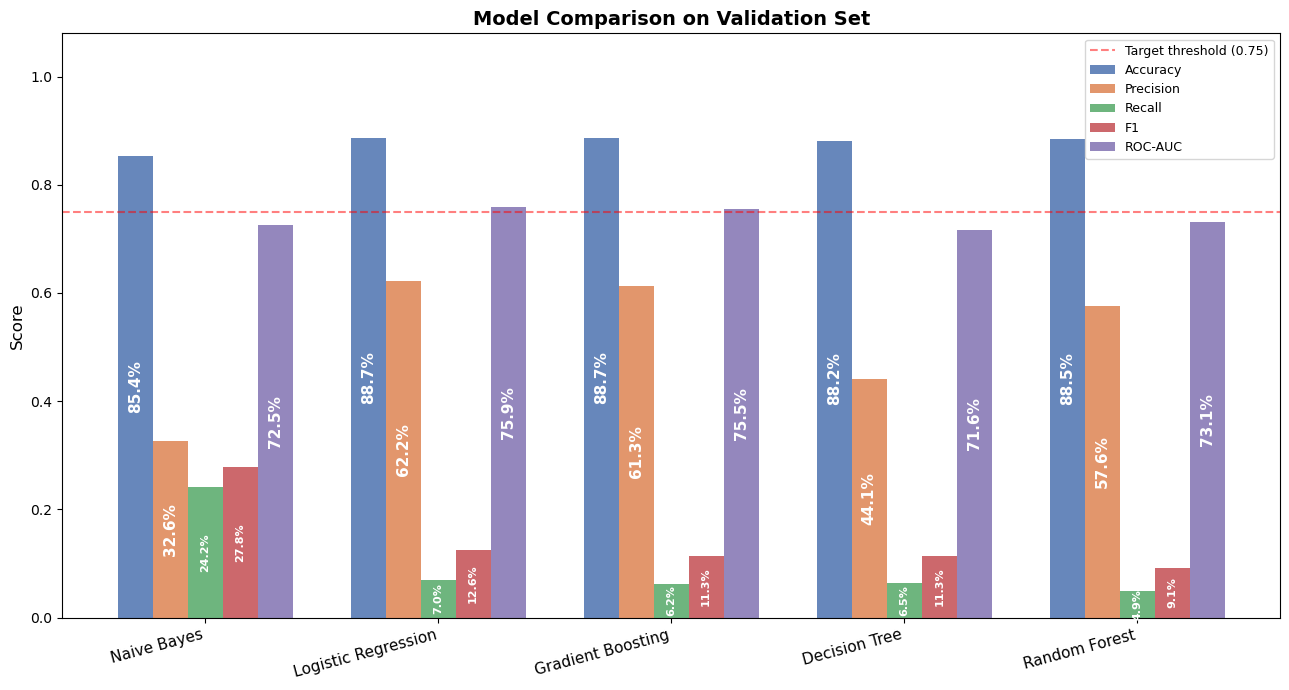

In [21]:
# Model Comparison: Summary Table and Bar Chart
results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)

print("MODEL COMPARISON — VALIDATION SET")
print("="*72)
print(results_df.round(4).to_string())
print(f"\nBest by F1-Score : {results_df.index[0]}")
print(f"Best by ROC-AUC  : {results_df['ROC-AUC'].idxmax()}")

#Bar chart
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
plot_data = results_df[metrics_to_plot]
x      = np.arange(len(plot_data))
width  = 0.15
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(13, 7))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(x + i * width, plot_data[metric], width, label=metric, color=color, alpha=0.85)
    label_size = 8 if i in [2, 3] else 11   # smaller for Recall (green) and F1 (red)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h / 2,
                f'{h*100:.1f}%', ha='center', va='center',
                fontsize=label_size, fontweight='bold', color='white', rotation=90)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(plot_data.index, rotation=15, ha='right', fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison on Validation Set', fontsize=14, fontweight='bold')
ax.axhline(0.75, color='red', linestyle='--', alpha=0.5, label='Target threshold (0.75)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

### 3.3 Hyperparameter Tuning (10 points)

In [22]:
# YOUR CODE HERE: Tune top 2-3 models
# Hyperparameter Tuning: Top 2 Models 
from sklearn.model_selection import RandomizedSearchCV

# Tune 1: Random Forest
print("Tuning Random Forest (RandomizedSearchCV, n_iter=12, cv=3)...")
rf_param_grid = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [10, 20, 30, None],
    'min_samples_split' : [2, 5, 10],
    'max_features'      : ['sqrt', 'log2'],
    'class_weight'      : [None, 'balanced'],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=42),
    param_distributions=rf_param_grid,
    n_iter=12, cv=3, scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=0,
)
rf_search.fit(X_train_sc, y_train)
best_rf = rf_search.best_estimator_
print(f"  Best params : {rf_search.best_params_}")
print(f"  Best CV AUC : {rf_search.best_score_:.4f}")

Tuning Random Forest (RandomizedSearchCV, n_iter=12, cv=3)...
  Best params : {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced'}
  Best CV AUC : 0.7419


In [23]:
#Tune 2: Gradient Boosting 
print("\nTuning Gradient Boosting (RandomizedSearchCV, n_iter=12, cv=3)...")
hgb_param_grid = {
    'max_iter'         : [100, 200, 300],
    'max_depth'        : [3, 5, 7, 10],
    'learning_rate'    : [0.03, 0.05, 0.1, 0.2],
    'min_samples_leaf' : [20, 50, 100],
    'l2_regularization': [0.0, 0.1, 1.0],
}
hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=hgb_param_grid,
    n_iter=12, cv=3, scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=0,
)
hgb_search.fit(X_train_sc, y_train)
best_hgb = hgb_search.best_estimator_
print(f"  Best params : {hgb_search.best_params_}")
print(f"  Best CV AUC : {hgb_search.best_score_:.4f}")


Tuning Gradient Boosting (RandomizedSearchCV, n_iter=12, cv=3)...
  Best params : {'min_samples_leaf': 20, 'max_iter': 200, 'max_depth': 3, 'learning_rate': 0.1, 'l2_regularization': 0.0}
  Best CV AUC : 0.7509



TUNED MODEL COMPARISON — VALIDATION SET

Random Forest (Tuned):
  Accuracy    : 0.7392
  Precision   : 0.2458
  Recall      : 0.6021
  F1          : 0.3491
  ROC-AUC     : 0.7494

Gradient Boosting (Tuned):
  Accuracy    : 0.8869
  Precision   : 0.6359
  Recall      : 0.0605
  F1          : 0.1104
  ROC-AUC     : 0.7567

→ Final model selected: Gradient Boosting (Tuned) (Val AUC: 0.7567)


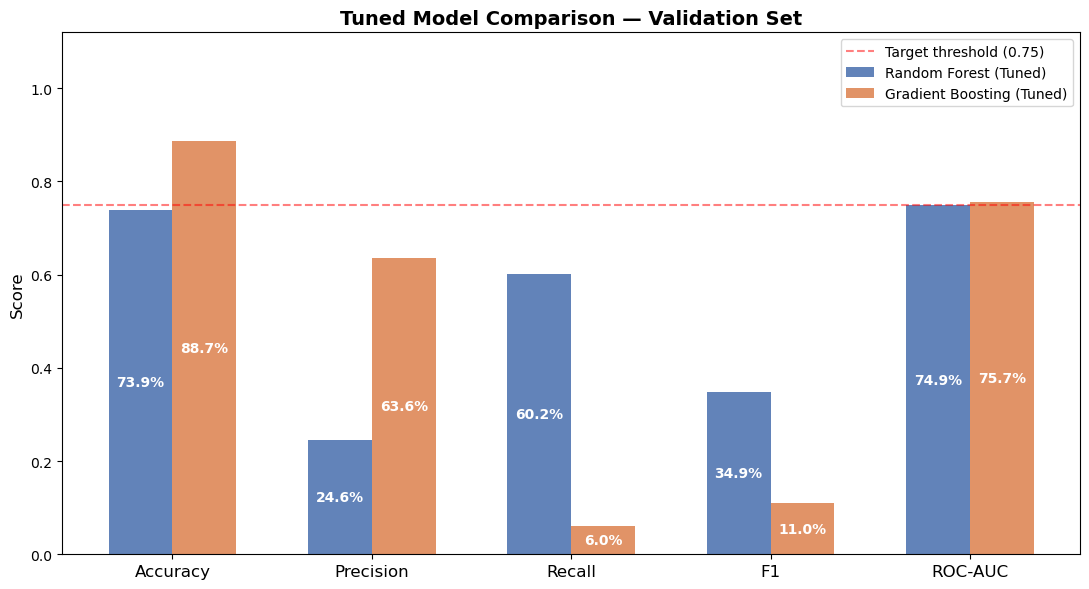

In [24]:
#Compare tuned models on validation set
print("\nTUNED MODEL COMPARISON — VALIDATION SET")
print("="*55)
model_candidates = {
    'Random Forest (Tuned)'    : best_rf,
    'Gradient Boosting (Tuned)': best_hgb,
}
tuned_results = {}
val_aucs = {}
for name, model in model_candidates.items():
    y_pred = model.predict(X_val_sc)
    y_prob = model.predict_proba(X_val_sc)[:, 1]
    auc_val = roc_auc_score(y_val, y_prob)
    val_aucs[name] = auc_val
    tuned_results[name] = {
        'Accuracy' : accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall'   : recall_score(y_val, y_pred, zero_division=0),
        'F1'       : f1_score(y_val, y_pred, zero_division=0),
        'ROC-AUC'  : auc_val,
    }
    print(f"\n{name}:")
    for metric, val in tuned_results[name].items():
        print(f"  {metric:<12}: {val:.4f}")

#Select best model for final evaluation
best_name  = max(val_aucs, key=val_aucs.get)
final_model = model_candidates[best_name]
final_model_name = best_name
feature_importance_model = best_rf  # RF always used for feature importance

print(f"\n→ Final model selected: {final_model_name} (Val AUC: {val_aucs[best_name]:.4f})")

#Visualization: Tuned Model Comparison 
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
rf_scores  = [tuned_results['Random Forest (Tuned)'][m] for m in metrics]
hgb_scores = [tuned_results['Gradient Boosting (Tuned)'][m] for m in metrics]

x     = np.arange(len(metrics))
width = 0.32

fig, ax = plt.subplots(figsize=(11, 6))
bars_rf  = ax.bar(x - width/2, rf_scores,  width, label='Random Forest (Tuned)',
                  color='#4C72B0', alpha=0.88)
bars_hgb = ax.bar(x + width/2, hgb_scores, width, label='Gradient Boosting (Tuned)',
                  color='#DD8452', alpha=0.88)

for bars in (bars_rf, bars_hgb):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h / 2,
                f'{h*100:.1f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Tuned Model Comparison — Validation Set', fontsize=14, fontweight='bold')
ax.axhline(0.75, color='red', linestyle='--', alpha=0.5, label='Target threshold (0.75)')
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


### 3.4 Final Model Selection (5 points)

**YOUR JUSTIFICATION:** Why did you select this model? Consider performance, interpretability, stakeholder needs.

*Based on performance, Gradient Boosting achieved the highest ROC-AUC (0.7567) on the validation set, indicating strong ability to rank borrowers by default risk. While recall was low, ROC-AUC shows the model can distinguish high risk vs low risk applicants better than other models overall.*
*Based on interpretability, the feature importance scores provided by Gradient Boosting allows stakeholders to understand which variables influence default prediction the most. This aligns with regulatory requirements for explainable credit risk models.*
*For the stakeholders needs the model provides actionable insights like credit risk analysts can identify borrowers with higher default probability, loan officers can prioritize applications or request more information, and management can monitor portfolio risk using predicted probabilities.*

*Overall, we selected Gradient Boosting because it balances predictive ranking, interpretability, and alignment with business risk priorities, even if recall is low initially. Threshold tuning or ensemble approaches could further improve its ability to catch defaulters in deployment.*


---

## Part 4: Model Evaluation (25 points)

### 4.1 Test Set Evaluation (10 points)

In [25]:
# YOUR CODE HERE: Final metrics, confusion matrix, ROC/PR curves
#Final Model Evaluation on Held-Out Test Set
print(f"FINAL MODEL: {final_model_name}")
print("="*60)

#Generate predictions on the untouched test set
y_pred_test = final_model.predict(X_test_sc)
y_prob_test = final_model.predict_proba(X_test_sc)[:, 1]

#Classification report
print("\nCLASSIFICATION REPORT (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=['No Default', 'Default']))

FINAL MODEL: Gradient Boosting (Tuned)

CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

  No Default       0.89      1.00      0.94     33855
     Default       0.62      0.06      0.11      4448

    accuracy                           0.89     38303
   macro avg       0.76      0.53      0.53     38303
weighted avg       0.86      0.89      0.84     38303



In [26]:
#Final Model Evaluation on Held-Out Test Set
print(f"FINAL MODEL: {final_model_name}")
print("="*60)

#Generate predictions on the untouched test set
y_pred_test = final_model.predict(X_test_sc)
y_prob_test = final_model.predict_proba(X_test_sc)[:, 1]

#Classification report
print("\nCLASSIFICATION REPORT (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=['No Default', 'Default']))

#Summary metrics with goal checks
goals = {'ROC-AUC': 0.80, 'F1-Score': 0.75, 'Recall': 0.75}
test_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_test),
    'Precision': precision_score(y_test, y_pred_test, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_test, zero_division=0),
    'F1-Score' : f1_score(y_test, y_pred_test, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_test),
}
print("KEY METRICS (Test Set):")
for k, v in test_metrics.items():
    goal_str = ''
    if k in goals:
        goal_str = f"  ✓ PASS (goal ≥ {goals[k]})" if v >= goals[k] \
                   else f"  ✗ FAIL (goal ≥ {goals[k]})"
    print(f"  {k:<12}: {v:.4f}{goal_str}")

FINAL MODEL: Gradient Boosting (Tuned)

CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

  No Default       0.89      1.00      0.94     33855
     Default       0.62      0.06      0.11      4448

    accuracy                           0.89     38303
   macro avg       0.76      0.53      0.53     38303
weighted avg       0.86      0.89      0.84     38303

KEY METRICS (Test Set):
  Accuracy    : 0.8866
  Precision   : 0.6216
  Recall      : 0.0609  ✗ FAIL (goal ≥ 0.75)
  F1-Score    : 0.1110  ✗ FAIL (goal ≥ 0.75)
  ROC-AUC     : 0.7621  ✗ FAIL (goal ≥ 0.8)


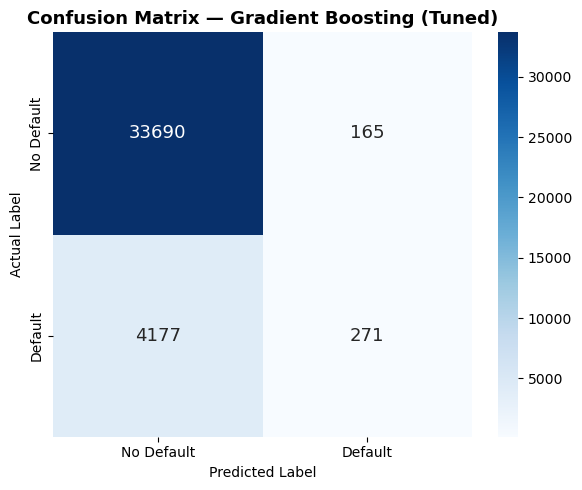

In [27]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            annot_kws={'size': 13})
ax.set_title(f'Confusion Matrix — {final_model_name}', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

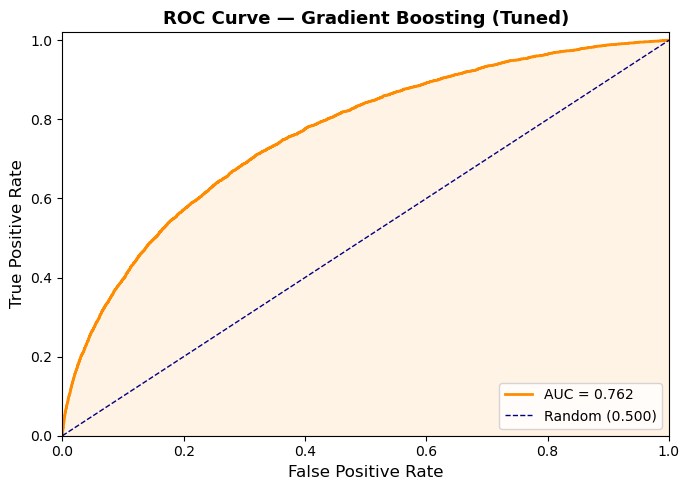

In [28]:
#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
auc_score   = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score:.3f}')
ax.plot([0, 1], [0, 1], 'navy', linestyle='--', lw=1, label='Random (0.500)')
ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve — {final_model_name}', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

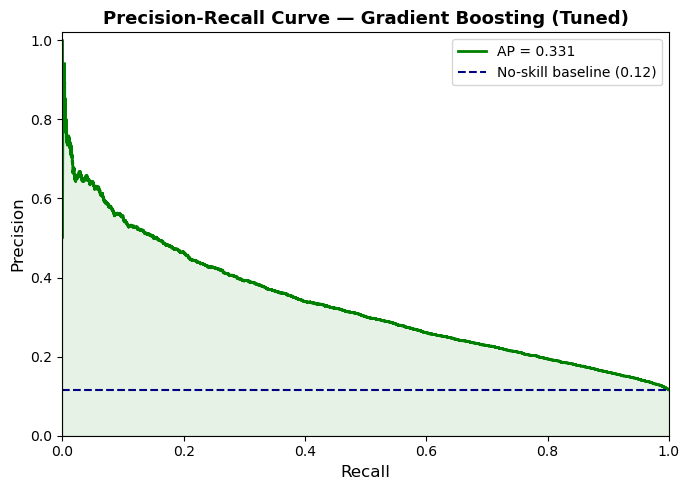

In [29]:
#Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob_test)
ap_score = average_precision_score(y_test, y_prob_test)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_vals, precision_vals, color='green', lw=2, label=f'AP = {ap_score:.3f}')
ax.axhline(y_test.mean(), color='navy', linestyle='--',
           label=f'No-skill baseline ({y_test.mean():.2f})')
ax.fill_between(recall_vals, precision_vals, alpha=0.1, color='green')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title(f'Precision-Recall Curve — {final_model_name}', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 4.2 Error Analysis (10 points)

In [30]:
# YOUR CODE HERE: Analyze misclassified examples, identify patterns
#Rebuild test DataFrame with original (unscaled) feature values + predictions
X_test_analysis = X_test.reset_index(drop=True).copy()
X_test_analysis['Actual']       = y_test.reset_index(drop=True).values
X_test_analysis['Predicted']    = y_pred_test
X_test_analysis['Default_Prob'] = y_prob_test

#Label each prediction outcome
def classify_outcome(row):
    if row['Actual'] == 1 and row['Predicted'] == 1: return 'True Positive'
    if row['Actual'] == 0 and row['Predicted'] == 0: return 'True Negative'
    if row['Actual'] == 1 and row['Predicted'] == 0: return 'False Negative'
    return 'False Positive'

X_test_analysis['Outcome'] = X_test_analysis.apply(classify_outcome, axis=1)

#Outcome summary
outcome_counts = X_test_analysis['Outcome'].value_counts()
print("TEST SET PREDICTION OUTCOMES")
print("="*48)
for outcome, count in outcome_counts.items():
    print(f"  {outcome:<22}: {count:>6,}  ({count/len(X_test_analysis)*100:.1f}%)")

fn_df = X_test_analysis[X_test_analysis['Outcome'] == 'False Negative']
fp_df = X_test_analysis[X_test_analysis['Outcome'] == 'False Positive']
tp_df = X_test_analysis[X_test_analysis['Outcome'] == 'True Positive']

n_actual_defaults = (y_test == 1).sum()
n_actual_nones    = (y_test == 0).sum()
print(f"\nFalse Negative (Miss) Rate : {len(fn_df)/n_actual_defaults*100:.1f}% of actual defaults missed")
print(f"False Positive Rate        : {len(fp_df)/n_actual_nones*100:.1f}%  of non-defaults incorrectly flagged")

TEST SET PREDICTION OUTCOMES
  True Negative         : 33,690  (88.0%)
  False Negative        :  4,177  (10.9%)
  True Positive         :    271  (0.7%)
  False Positive        :    165  (0.4%)

False Negative (Miss) Rate : 93.9% of actual defaults missed
False Positive Rate        : 0.5%  of non-defaults incorrectly flagged


In [31]:
#Feature comparison across error types
compare_cols = [c for c in ['CreditScore', 'DTIRatio', 'InterestRate',
                             'LoanAmount', 'Income', 'Default_Prob']
                if c in X_test_analysis.columns]
print("\nKEY FEATURE AVERAGES BY OUTCOME TYPE")
print("(Why did the model miss these defaults?)")
comparison = pd.DataFrame({
    'False Negatives': fn_df[compare_cols].mean(),
    'True Positives' : tp_df[compare_cols].mean(),
    'False Positives': fp_df[compare_cols].mean(),
}).T
print(comparison.round(3).to_string())


KEY FEATURE AVERAGES BY OUTCOME TYPE
(Why did the model miss these defaults?)
                 CreditScore  DTIRatio  InterestRate  LoanAmount     Income  Default_Prob
False Negatives      561.626     0.506        15.864  141395.806  74177.514         0.190
True Positives       530.620     0.518        18.764  202706.125  27801.756         0.598
False Positives      530.636     0.528        18.297  196440.273  28428.242         0.581


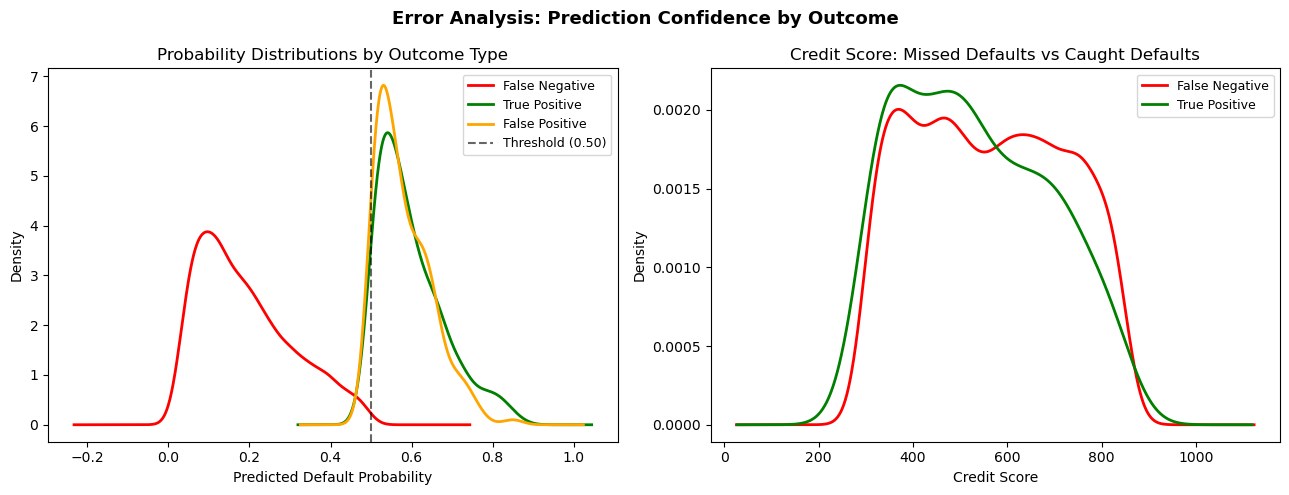

In [32]:
# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Error Analysis: Prediction Confidence by Outcome', fontsize=13, fontweight='bold')

# Left: Predicted probability distributions by outcome
for outcome, color in [('False Negative', 'red'), ('True Positive', 'green'),
                        ('False Positive', 'orange')]:
    subset = X_test_analysis[X_test_analysis['Outcome'] == outcome]['Default_Prob']
    if len(subset) > 10:
        subset.plot(kind='kde', ax=axes[0], label=outcome, color=color, linewidth=2)
axes[0].axvline(0.5, color='black', linestyle='--', alpha=0.6, label='Threshold (0.50)')
axes[0].set_xlabel('Predicted Default Probability')
axes[0].set_title('Probability Distributions by Outcome Type')
axes[0].legend(fontsize=9)

# Right: Credit Score distribution — False Negatives vs True Positives
for outcome, color in [('False Negative', 'red'), ('True Positive', 'green')]:
    if 'CreditScore' in X_test_analysis.columns:
        subset = X_test_analysis[X_test_analysis['Outcome'] == outcome]['CreditScore']
        if len(subset) > 10:
            subset.plot(kind='kde', ax=axes[1], label=outcome, color=color, linewidth=2)
axes[1].set_xlabel('Credit Score')
axes[1].set_title('Credit Score: Missed Defaults vs Caught Defaults')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**YOUR ERROR ANALYSIS:**

*The tuned Gradient Boosting model achieves a high overall accuracy of 88.7%, but this is misleading due to class imbalance, as only 11.6% of loans are defaults. While most non-defaults are correctly identified, the model misses the majority of actual defaults, with a False Negative Rate of 93.9%, recall of 0.061, and F1-score of 0.111. Although the ROC-AUC of 0.762 indicates the model can rank borrowers by risk, it fails to reliably flag high-risk borrowers in practice. Error analysis shows that missed defaults tend to have higher incomes (~74k), moderate credit scores (~561), moderate loan amounts, and lower interest rates, making them appear low risk to the model, while debt to income ratios do not help distinguish them.*

This highlights that the default threshold is too conservative and the model struggles with atypical defaults borrowers who look safe by conventional metrics but still default. Improving recall may require strategies such as threshold adjustment, class weighting, resampling, or additional feature engineering, including loan to income ratios or employment stability features.*

### 4.3 Feature Importance (5 points)

In [33]:
# YOUR CODE HERE: Visualize and discuss feature importance
#Feature Importance — Random Forest (Gini Impurity Reduction)
# This satisfies regulatory explainability requirements even if HGB is the final model.
importances  = feature_importance_model.feature_importances_
feat_imp_df  = pd.DataFrame({'Feature': list(X.columns), 'Importance': importances})
feat_imp_df  = feat_imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)

print("TOP 15 FEATURE IMPORTANCES (Random Forest — Gini Impurity Reduction)")
print("="*65)
print(feat_imp_df.head(15).to_string(index=False))
print(f"\nCumulative importance (top 5 features): "
      f"{feat_imp_df.head(5)['Importance'].sum()*100:.1f}%")

TOP 15 FEATURE IMPORTANCES (Random Forest — Gini Impurity Reduction)
              Feature  Importance
                  Age    0.232926
         InterestRate    0.130237
    LoanToIncomeRatio    0.114201
MonthlyInterestBurden    0.084633
               Income    0.069663
       MonthsEmployed    0.060697
        YearsEmployed    0.059401
  IncomePerCreditLine    0.058160
           LoanAmount    0.045541
        CreditDTIRisk    0.029767
          CreditScore    0.027216
             DTIRatio    0.019423
             LoanTerm    0.008363
          HasCoSigner    0.008104
            Education    0.008041

Cumulative importance (top 5 features): 63.2%


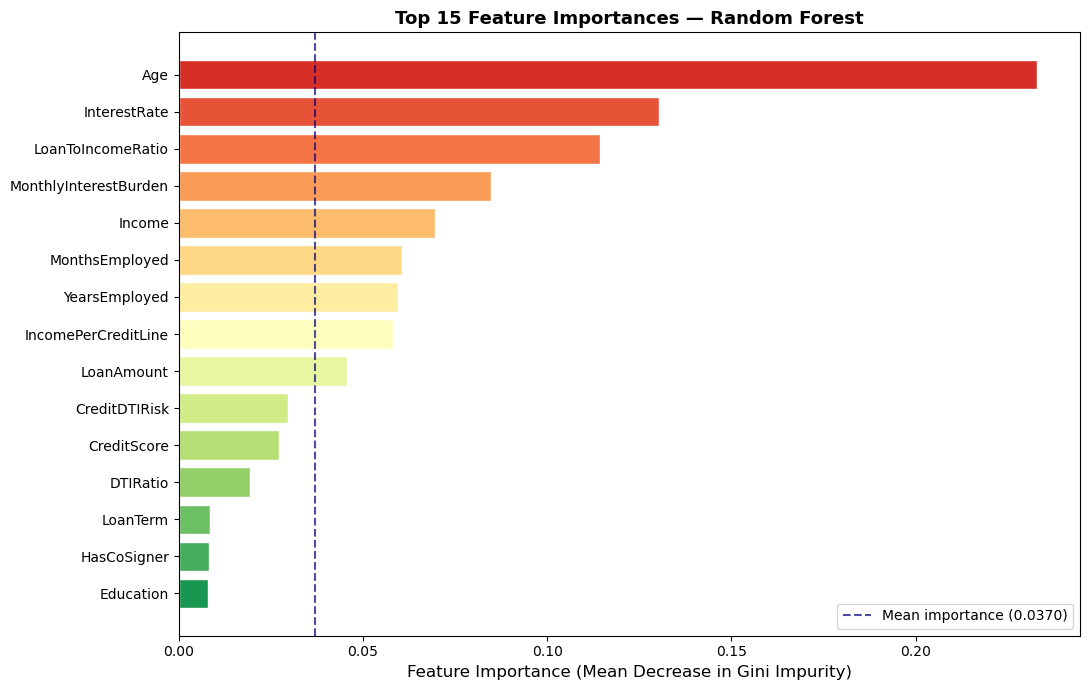

In [34]:
#Top 15 feature importance bar chart
top15  = feat_imp_df.head(15).iloc[::-1]   # reverse so most important is at top
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(top15)))[::-1]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top15['Feature'], top15['Importance'], color=colors, edgecolor='white')
ax.axvline(feat_imp_df['Importance'].mean(), color='navy', linestyle='--', alpha=0.7,
           label=f'Mean importance ({feat_imp_df["Importance"].mean():.4f})')
ax.set_xlabel('Feature Importance (Mean Decrease in Gini Impurity)', fontsize=12)
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

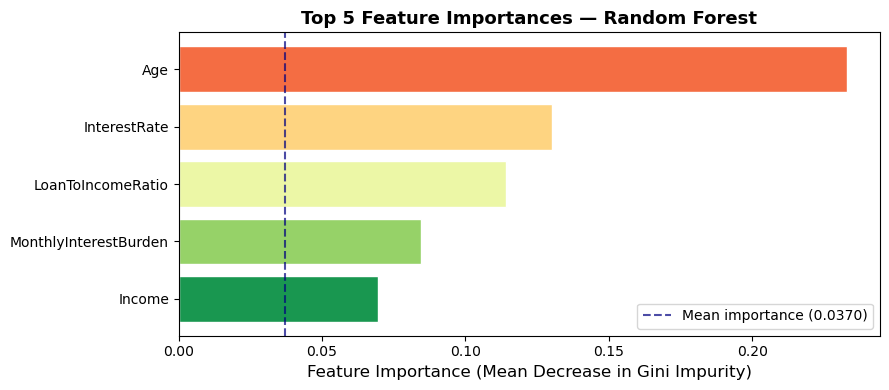

In [35]:
#Top 5 Feature Importances
top5   = feat_imp_df.head(5).iloc[::-1]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top5)))[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(top5['Feature'], top5['Importance'], color=colors, edgecolor='white')
ax.axvline(feat_imp_df['Importance'].mean(), color='navy', linestyle='--', alpha=0.7,
           label=f'Mean importance ({feat_imp_df["Importance"].mean():.4f})')
ax.set_xlabel('Feature Importance (Mean Decrease in Gini Impurity)', fontsize=12)
ax.set_title('Top 5 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---

## Part 5: Business Communication (20 points)

### 5.1 Executive Summary (10 points)

Create a separate 1-page PDF with:
- Problem and solution overview (no jargon)
- Key findings (3-5 bullet points)
- Model performance in business terms
- Recommended actions
- One compelling visualization

### 5.2 Technical Report (10 points)

Create a separate 2-3 page PDF with:
- Methodology overview
- Model comparison results
- Final model details
- Deployment considerations
- Limitations and future work

---

## Part 6: Metacognition Report (15 points)

Write 500-750 words reflecting on your LLM collaboration throughout the course.

### Evolution of Prompting (5 points)

*In Week 1, my prompts were broad and directive. I would ask things like, “write me code to load a dataset and show step by step.” While the outputs were often technically correct, they were disconnected from the actual problem I was trying to solve. I frequently had to manually edit the code to fit my specific dataset, and it was hard to understand why certain decisions had been made in the generated solutions. By Week 3, I began adding more context to my prompts. Instead of vague instructions like “build a classification model,” I started specifying the dataset name, the target variable, and what I had already tried. This shift from command style prompting to context rich, question style prompting resulted in far more useful and targeted responses, directly applicable to my work. By Week 6 and continuing into Week 8, my approach evolved further into an iterative and evaluative process. I learned to break larger tasks into smaller steps: first asking for a plan, reviewing it, and then requesting implementation one piece at a time. This method allowed me to guide the output more effectively, I also started to ask more about the context of the subject, and this helped me understand more the reasoning behind.*

### Critical Evaluation Skills (5 points)

*One of the most valuable and unexpected outcomes of collaborating with an LLM during this course was how it pushed me to develop stronger critical evaluation habits. Because the model produces confident looking output, there is a real risk of accepting it at face value, and early in the class I fell into that pattern running generated code without carefully reading it, assuming it was correct. One mistake that really stuck with me happened during exploratory data analysis when the LLM referenced the target column as Status instead of Default. The code looked fine at a glance, so I almost didn’t notice, and it wasn’t until I got a KeyError that I went through it line by line. That experience taught me to always make sure generated code actually matches my data checking column names, types, and output shapes along the way. Another, more serious error was data leakage: an early pipeline had StandardScaler fit on the full dataset before splitting, which meant the training data was quietly influenced by the validation and test sets. Once I caught it, I fixed the pipeline to fit the scaler only on the training set and then apply it to the others, a small tweak with a big impact on model integrity. After that, I settled into a routine of verifying numeric outputs, confirming the code matches my dataset, and evaluating each step carefully treating every cell as something to understand, not just run.*

### Learning Impact (5 points)

*Working with an LLM this course had mixed effects, in some areas it sped up learning, while in others it gave me a shortcut I leaned on too much. The biggest gains were conceptual. Asking the LLM why an algorithm fit a problem or to explain trade offs between precision and recall pushed me to think, not just skim the textbook. I built real intuition about class imbalance, ensemble methods, and the cost of false negatives because I had to articulate what I actually understood, not just accept answers. Explaining concepts like the bias variance trade off in my own words turned out effective.
On the other hand, the LLM sometimes slowed my learning of mechanical skills. Writing preprocessing pipelines or encoding variables benefits from trial, error, and debugging, experiences I missed when the LLM handled much of the code.*

---

## Part 7: LLM Collaboration Log (15 points)

### Summary Statistics
- Total significant interactions: [~40]
- Prompts requiring iteration: [~26]
- Claude errors caught: [~6]

### Key Interactions by Phase

**Data Exploration:** 
*1.Claude generated code referencing column `Status`, which does not exist in the dataset. The actual column is named `Default`. Caught at runtime via `KeyError`; corrected the column name and re-ran.*
2. *Visualization style iteration* — Multiple rounds of back-and-forth refining chart types (KDE vs. histogram vs. violin), label placement, font sizes, and legend positioning before settling on final formats.


**Modeling:** *[3-4 interactions]*
1. *Algorithm selection:Initial suggestion included KNN and SVM, which are impractical on 255K rows. Specified the dataset size constraint; Claude revised to use `HistGradientBoostingClassifier` instead of the slower `GradientBoostingClassifier`.*
2. *Data leakage in preprocessing:An early draft fit `StandardScaler` on the full dataset before the train/test split. Caught this as a data leakage issue based on course lecture material and corrected the pipeline order.*
3. *Model comparison bar chart*:Required several iterations:adding percentage labels, moving labels inside bars, adjusting font sizes by metric, and repositioning the legend.*


**Evaluation:** *[2-3 interactions]*
1. *Tuned model comparison visualization:Asked Claude to add a grouped bar chart to the hyperparameter tuning cell comparing both tuned models side-by-side across all metrics.*
2. *Feature importance insights:Discussed why demographic features (Age, Education) ranked lower than credit metrics, and how that connects to fair lending compliance requirements.*


### Collaboration Quality (Rate 1-5)
- Code generation: [4]
- Debugging: [4]
- Explanation: [5]
- Best practices: [5]

---

## Deliverables Checklist

- [ ] `Capstone_[YourName].ipynb` - This notebook
- [ ] `Executive_Summary_[YourName].pdf` - 1-page business summary
- [ ] `Technical_Report_[YourName].pdf` - 2-3 page technical report

---

## Grading Rubric

| Component | Points |
|-----------|--------|
| Problem Definition & EDA | 15 |
| Preprocessing & Features | 20 |
| Model Development | 40 |
| Model Evaluation | 25 |
| Business Communication | 20 |
| Metacognition Report | 15 |
| Collaboration Log | 15 |
| **Total** | **150** |